## Sesión 44: Análisis de Outliers en Datasets

#### **Objetivo**: Identificar, analizar y manejar valores atípicos (outliers) en diferentes datasets

---


Librerías importadas correctamente
- DATASET 1: TITANIC - ANÁLISIS DE TARIFAS
- Dimensiones del dataset: (891, 15)
- Columnas disponibles: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

- Primeras filas:
      fare  pclass     sex   age
0   7.2500       3    male  22.0
1  71.2833       1  female  38.0
2   7.9250       3  female  26.0
3  53.1000       1  female  35.0
4   8.0500       3    male  35.0
- RESUMEN DE OUTLIERS - FARE
- Estadísticas básicas:
   • Total de valores: 891
   • Outliers detectados: 116
   • Porcentaje de outliers: 13.02%
   • Media: 32.20
   • Mediana: 14.45

- Cálculos IQR:
   • Q1 (Percentil 25): 7.91
   • Q3 (Percentil 75): 31.00
   • IQR (Q3 - Q1): 23.09
   • Límite inferior (Q1 - 1.5*IQR): -26.72
   • Límite superior (Q3 + 1.5*IQR): 65.63

- Rango completo:
   • Mínimo: 0.00
   • Máximo: 512.33

- Valores outliers detectados:
   • 10 outliers más bajos: [66.6  6

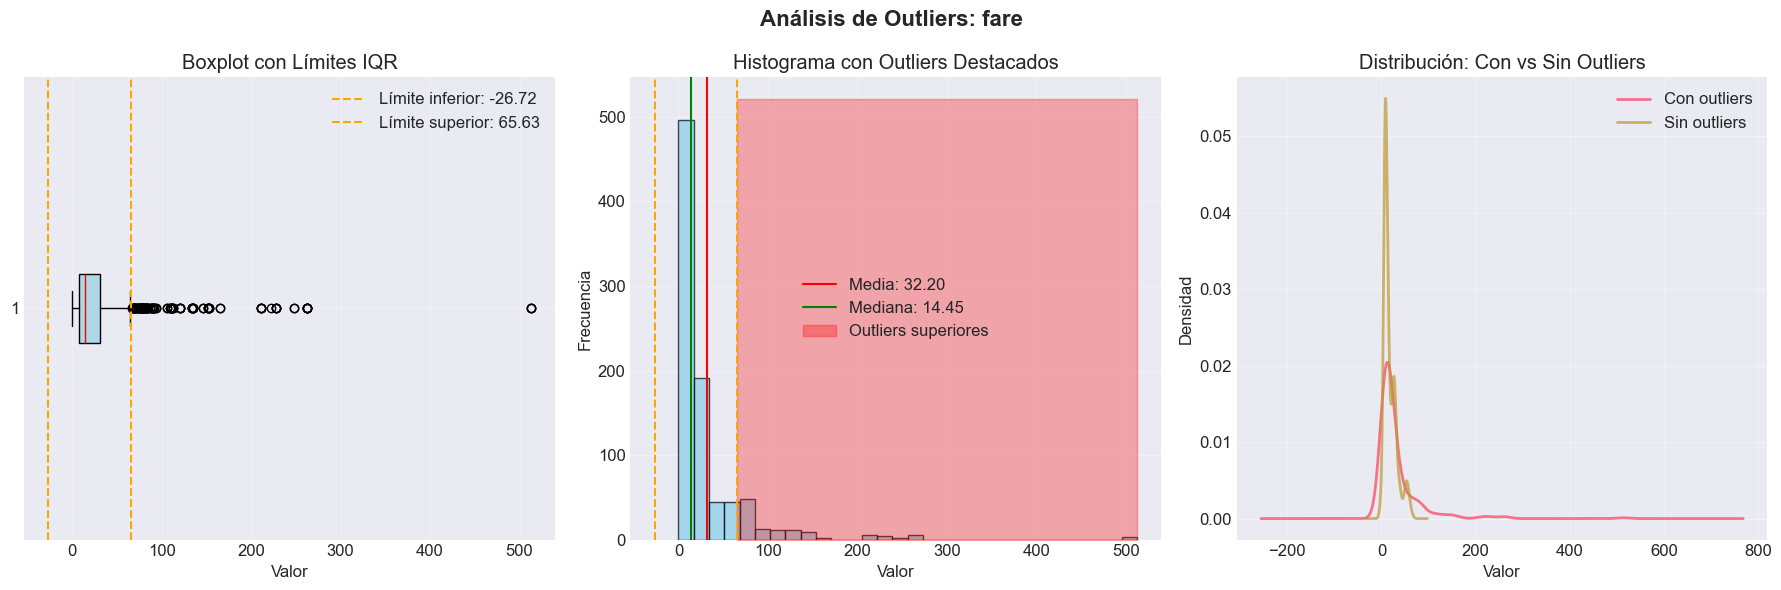


- OUTLIERS POR CLASE DE PASAJERO

Clase 1:
  • Número de outliers: 20
  • Porcentaje: 9.26%
  • Rango de outliers: 211.34 - 512.33

Clase 2:
  • Número de outliers: 7
  • Porcentaje: 3.80%
  • Rango de outliers: 65.00 - 73.50

Clase 3:
  • Número de outliers: 52
  • Porcentaje: 10.59%
  • Rango de outliers: 27.90 - 69.55

- TRANSFORMACIÓN LOGARÍTMICA DE 'fare'


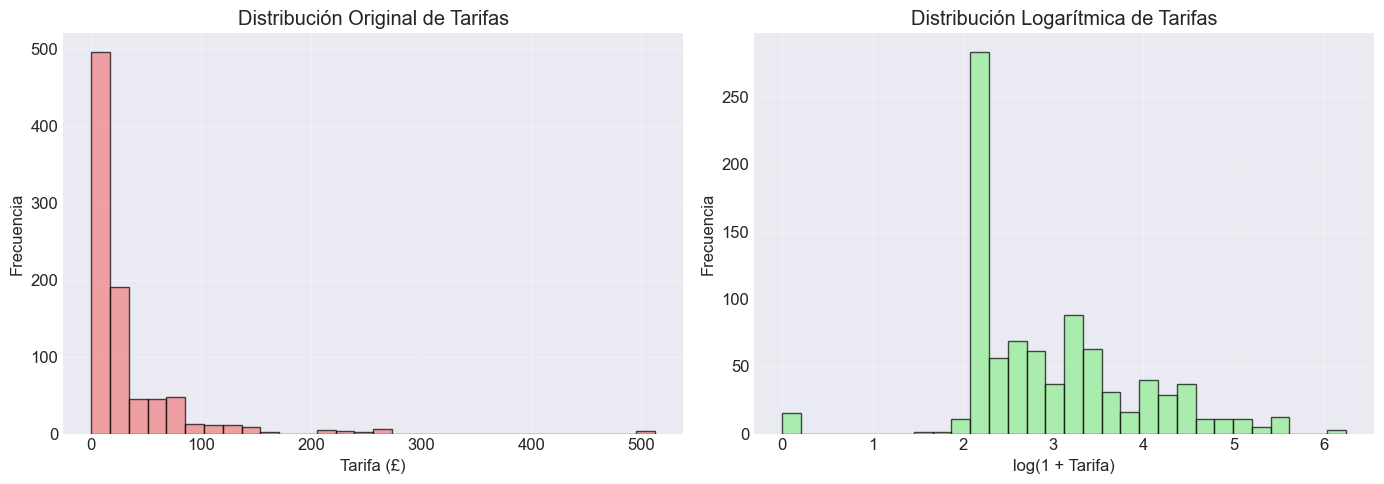


- Estadísticas después de transformación logarítmica:
  • Porcentaje de outliers original: 13.02%
  • Porcentaje de outliers transformado: 3.48%
  • Reducción en outliers: 9.54%


- DATASET 2: TIPS - ANÁLISIS DE CUENTAS
- Dimensiones del dataset: (244, 7)
- Columnas disponibles: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

- Primeras filas:
   total_bill   tip     sex smoker  day    time
0       16.99  1.01  Female     No  Sun  Dinner
1       10.34  1.66    Male     No  Sun  Dinner
2       21.01  3.50    Male     No  Sun  Dinner
3       23.68  3.31    Male     No  Sun  Dinner
4       24.59  3.61  Female     No  Sun  Dinner
- RESUMEN DE OUTLIERS - TOTAL_BILL
- Estadísticas básicas:
   • Total de valores: 244
   • Outliers detectados: 9
   • Porcentaje de outliers: 3.69%
   • Media: 19.79
   • Mediana: 17.80

- Cálculos IQR:
   • Q1 (Percentil 25): 13.35
   • Q3 (Percentil 75): 24.13
   • IQR (Q3 - Q1): 10.78
   • Límite inferior (Q1 - 1.5*IQR): -2.82
   • Límite super

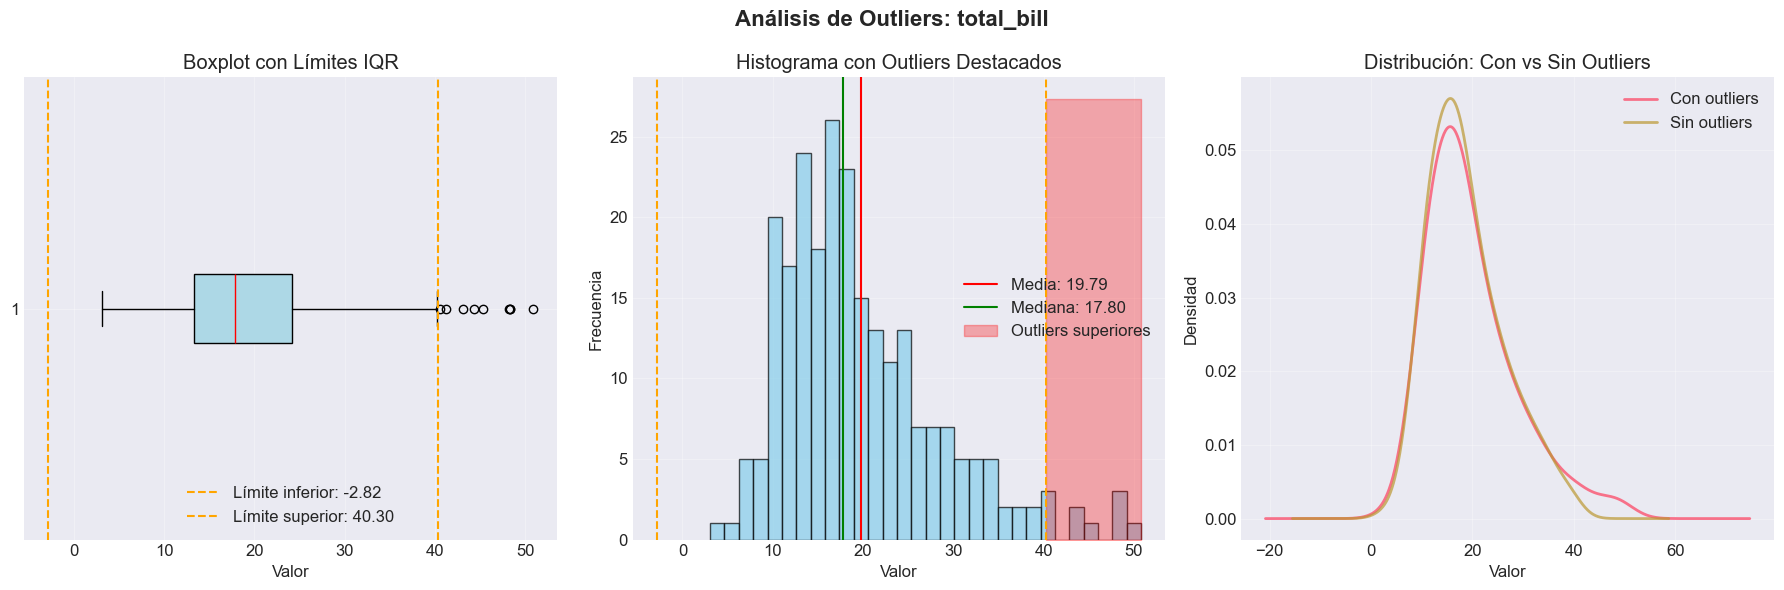


- OUTLIERS POR DÍA DE LA SEMANA
Sun: 2 outliers (2.6%)
Sat: 4 outliers (4.6%)
Thur: 5 outliers (8.1%)
Fri: 1 outliers (5.3%)


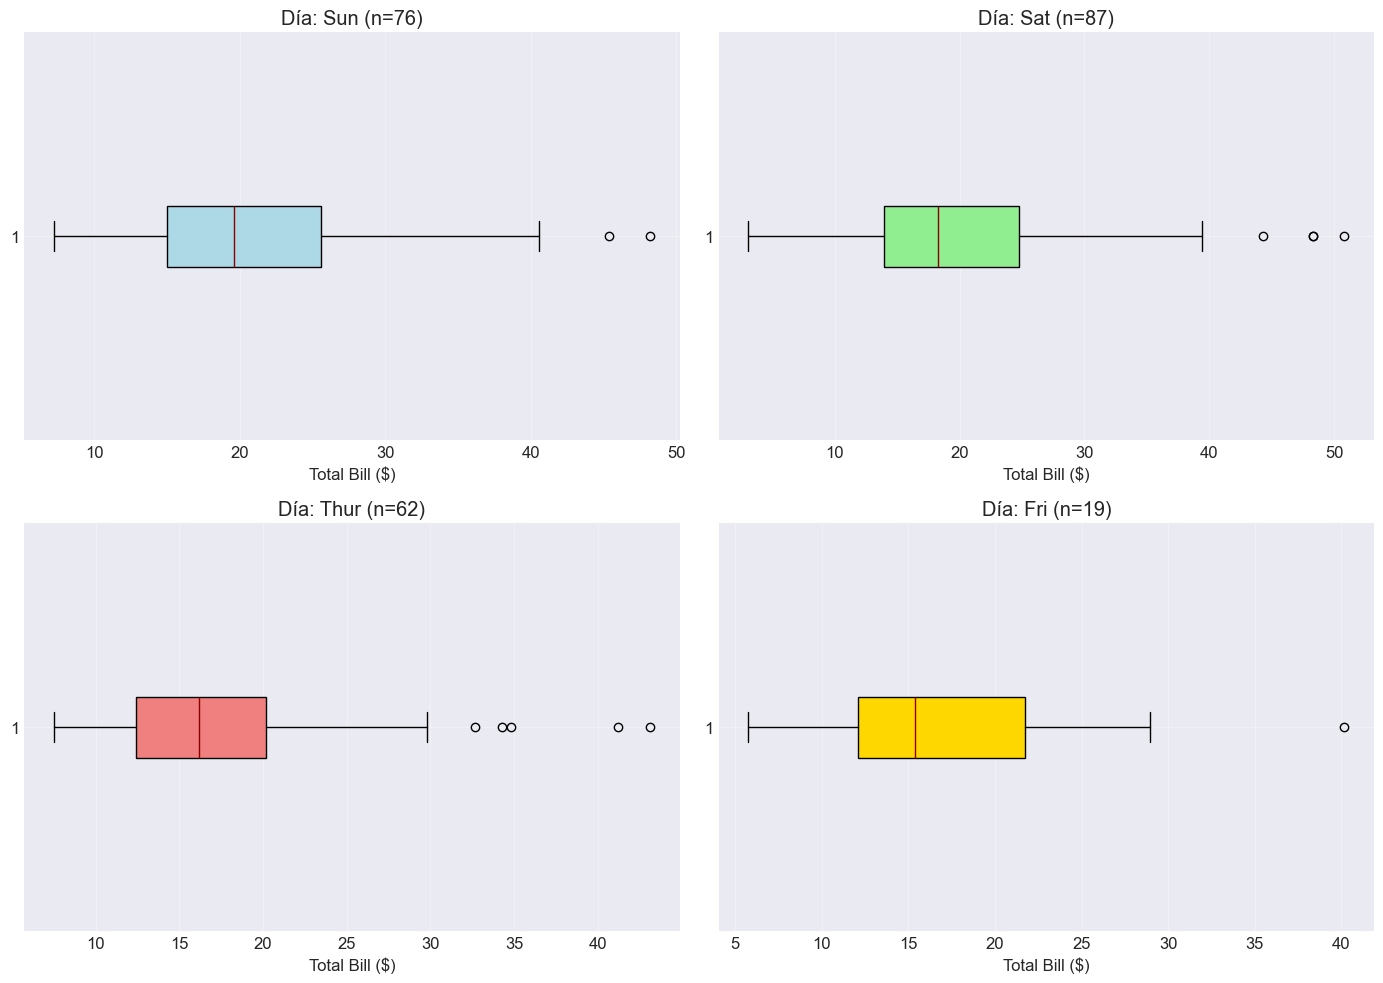


- COMPARACIÓN DE ESTRATEGIAS DE MANEJO

- Estadísticas comparativas:
----------------------------------------
Estrategia                Media      Desv Est   Reducción Desv 
----------------------------------------
Original                  $19.79     $8.90      -              
Sin outliers              $18.80     $7.44      16.4          %
Winsorizado (5-95%)       $19.60     $7.96      10.6          %
Log-transformado          -2.95      -0.41      N/A            
----------------------------------------


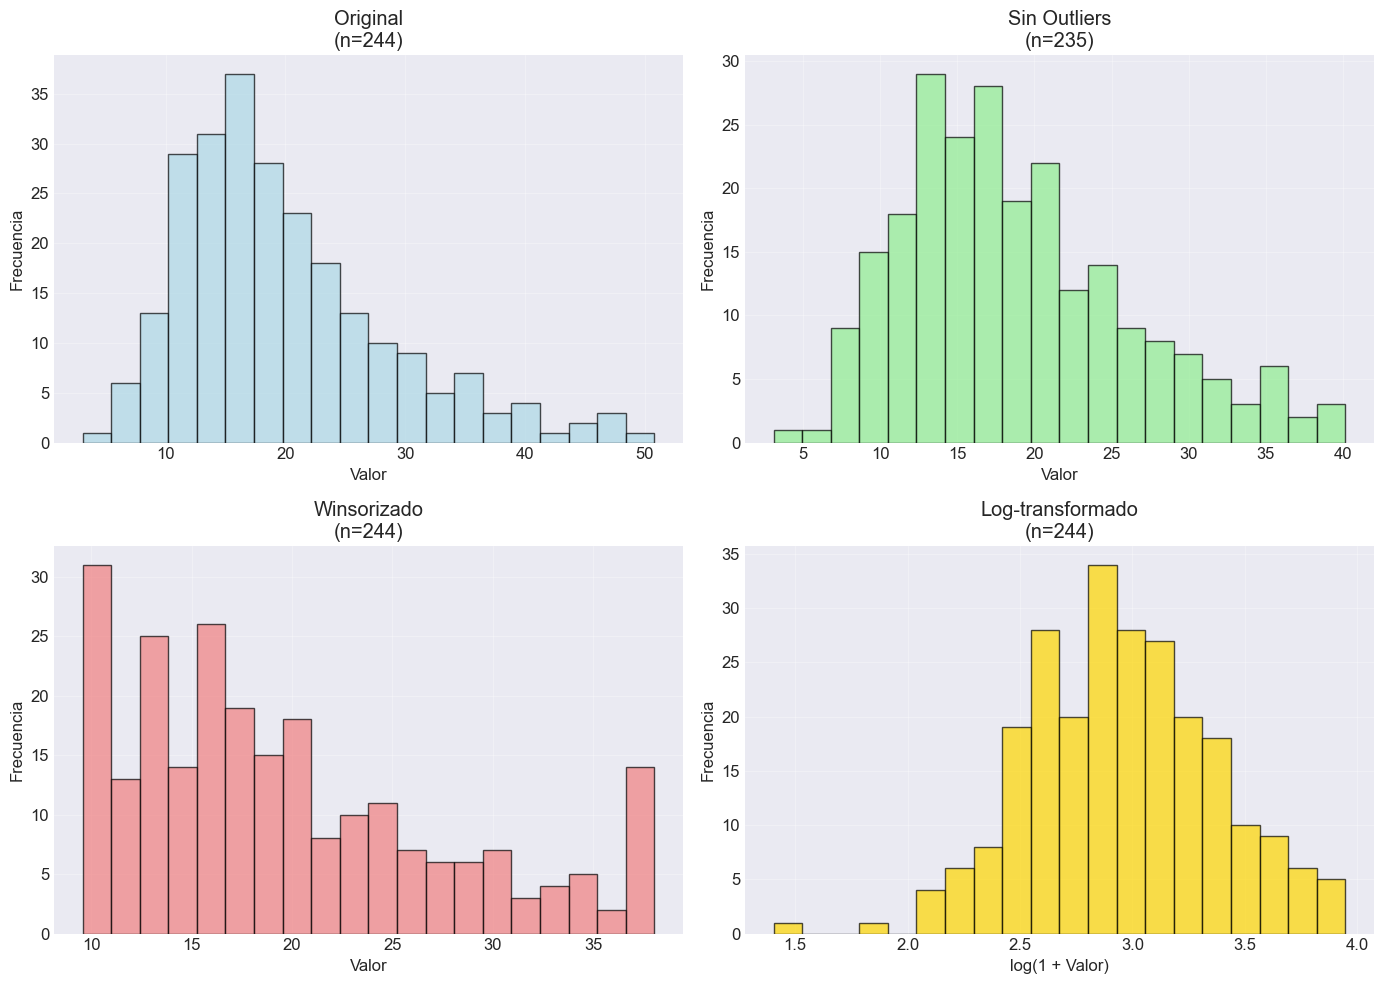



- DATASET 3: IRIS - ANÁLISIS DE LONGITUD DE PÉTALO
- Dimensiones del dataset: (150, 5)
- Especies únicas: ['setosa' 'versicolor' 'virginica']

- ANÁLISIS DE OUTLIERS POR ESPECIE
setosa: 4 outliers (8.0%)
versicolor: 1 outliers (2.0%)
virginica: 0 outliers (0.0%)


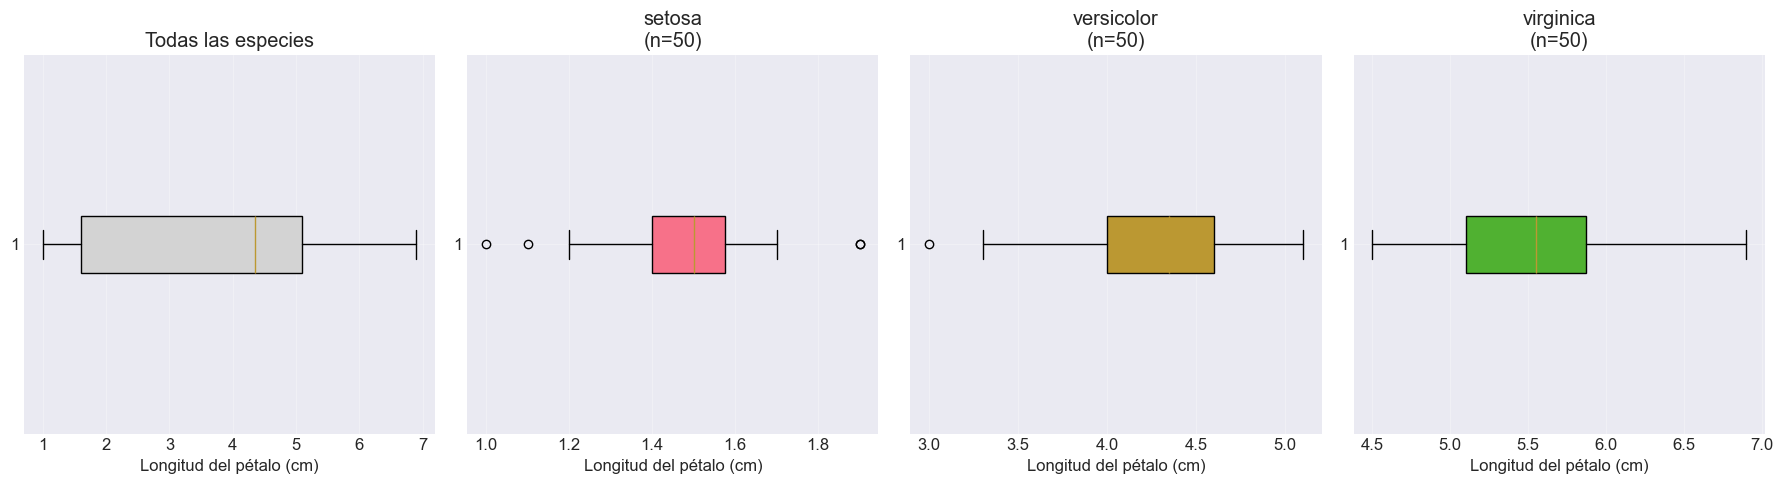

- RESUMEN COMPARATIVO DE LOS TRES ANÁLISIS

Dataset     Variable  n_outliers  %_outliers                 Recomendación                 Técnica sugerida
Titanic         fare         116   13.019080                      Mantener       Transformación logarítmica
   Tips   total_bill           9    3.688525             Analizar contexto Winsorización o modelos robustos
   Iris petal_length           0    0.000000 Mantener (son subpoblaciones)               Análisis por grupo


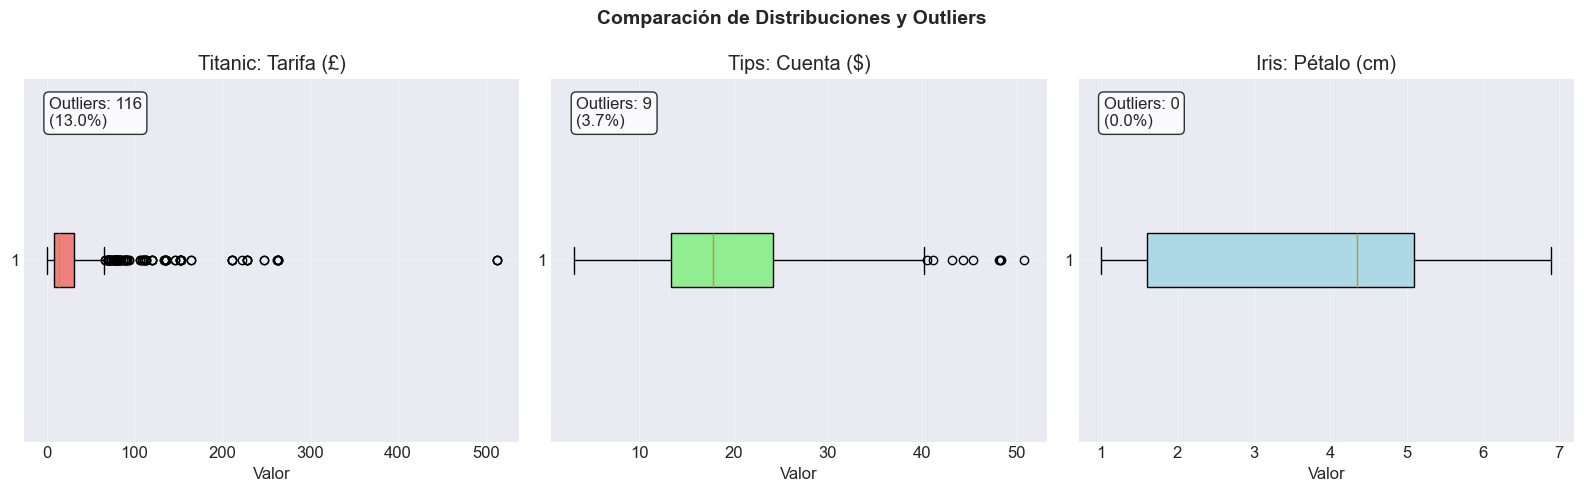

- DIAGRAMA DE DECISIÓN PARA MANEJO DE OUTLIERS

                ¿Tiene sentido el outlier en su contexto?
                        /                  \
                       /                    \
                 SÍ                        NO
                  |                          |
    ┌──────────────────────┐      ┌──────────────────────┐
    │ ¿Representa un grupo │      │ ¿Es error de medición│
    │      específico?     │      │    o digitación?     │
    └──────────┬───────────┘      └──────────┬───────────┘
               |                              |
         ┌─────┴─────┐                 ┌─────┴─────┐
         │           │                 │           │
     Análisis por   Mantener       Corregir o   Eliminar
        grupo        como dato    investigar     si es
                     válido                     irrelevante

    ┌─────────────────────────────────────────────────────┐
    │ ALTERNATIVAS GENERALES:                            │
    │ 1. Transformación (log

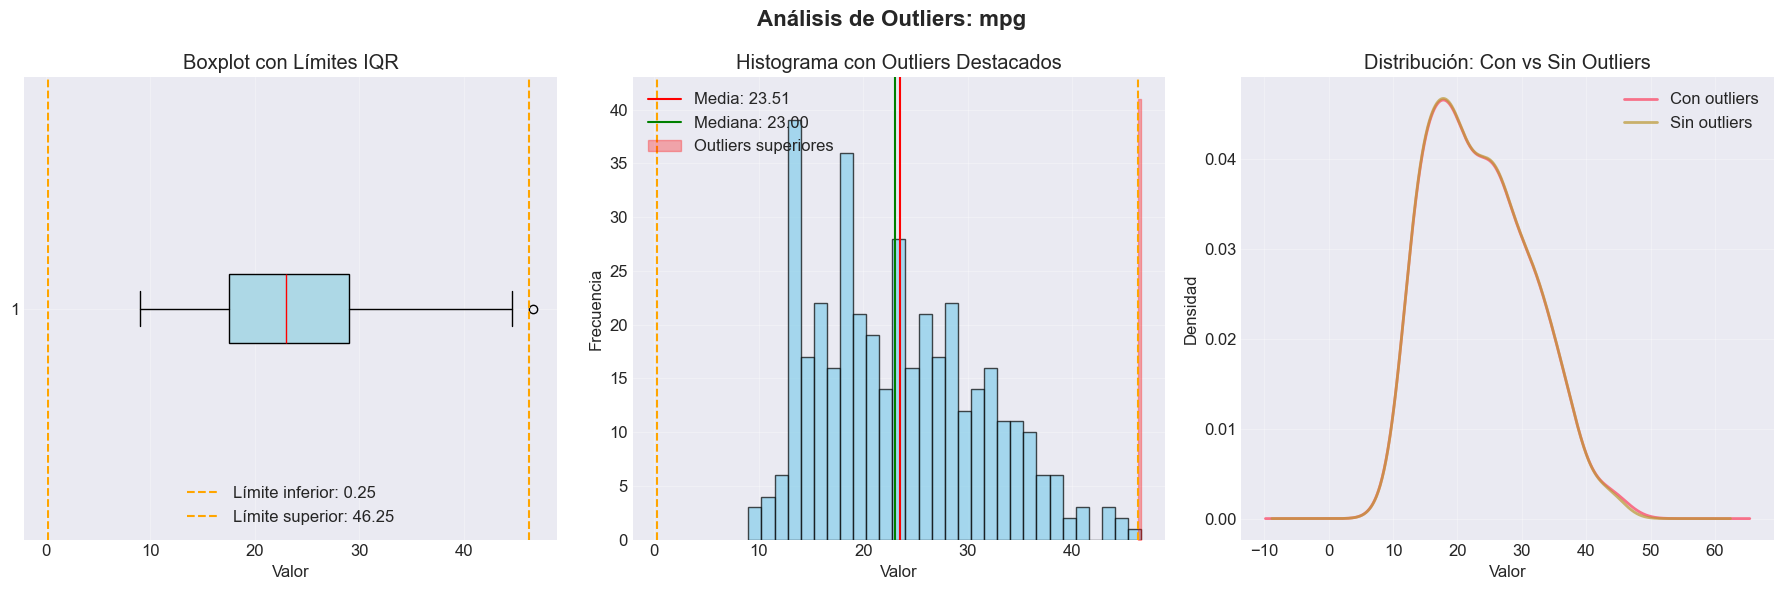


- RECOMENDACIÓN AUTOMÁTICA:
----------------------------------------
- Pocos outliers (<2%). Pueden mantenerse sin mayor impacto.

-  TÉCNICAS SUGERIDAS:
----------------------------------------
1. Transformación logarítmica: np.log1p(data)
2. Winsorización: reemplazar con percentiles 5 y 95
3. Análisis por subgrupos si existen categorías
4. Modelos robustos: Random Forest, XGBoost
5. Métricas robustas: mediana, IQR en lugar de media, desviación


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Mostrar todas las columnas en los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Librerías importadas correctamente")

# 2. Funciones auxiliares para análisis de outliers

def calcular_outliers_iqr(data, column_name):
    """
    Calcula outliers usando el método IQR (1.5 * IQR)
    
    Parameters:
    -----------
    data : pandas DataFrame
    column_name : str
        Nombre de la columna a analizar
    
    Returns:
    --------
    dict: Diccionario con estadísticas y outliers
    """
    # Filtrar valores no nulos
    serie = data[column_name].dropna()
    
    # Calcular estadísticas básicas
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    
    # Calcular límites
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    # Identificar outliers
    outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
    
    # Estadísticas
    stats_dict = {
        'columna': column_name,
        'n_total': len(serie),
        'n_outliers': len(outliers),
        'porcentaje_outliers': (len(outliers) / len(serie)) * 100,
        'media': serie.mean(),
        'mediana': serie.median(),
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'minimo': serie.min(),
        'maximo': serie.max(),
        'outliers': outliers
    }
    
    return stats_dict

def graficar_outliers(data, column_name, stats_dict):
    """
    Crea visualizaciones para análisis de outliers
    
    Parameters:
    -----------
    data : pandas DataFrame
    column_name : str
    stats_dict : dict
        Diccionario con estadísticas calculadas
    """
    # Crear figura con 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Análisis de Outliers: {column_name}', fontsize=16, fontweight='bold')
    
    # 1. Boxplot
    boxplot_data = axes[0].boxplot(data[column_name].dropna(), vert=False, patch_artist=True)
    boxplot_data['boxes'][0].set_facecolor('lightblue')
    boxplot_data['medians'][0].set_color('red')
    
    # Añadir líneas de límites
    axes[0].axvline(stats_dict['limite_inferior'], color='orange', linestyle='--', 
                   label=f"Límite inferior: {stats_dict['limite_inferior']:.2f}")
    axes[0].axvline(stats_dict['limite_superior'], color='orange', linestyle='--',
                   label=f"Límite superior: {stats_dict['limite_superior']:.2f}")
    
    axes[0].set_title('Boxplot con Límites IQR')
    axes[0].set_xlabel('Valor')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Histograma
    axes[1].hist(data[column_name].dropna(), bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    
    # Añadir líneas de referencia
    axes[1].axvline(stats_dict['media'], color='red', linestyle='-', 
                   label=f"Media: {stats_dict['media']:.2f}")
    axes[1].axvline(stats_dict['mediana'], color='green', linestyle='-',
                   label=f"Mediana: {stats_dict['mediana']:.2f}")
    axes[1].axvline(stats_dict['limite_inferior'], color='orange', linestyle='--')
    axes[1].axvline(stats_dict['limite_superior'], color='orange', linestyle='--')
    
    # Sombrear área de outliers
    ylim = axes[1].get_ylim()
    axes[1].fill_betweenx(ylim, stats_dict['limite_superior'], stats_dict['maximo'], 
                         alpha=0.3, color='red', label='Outliers superiores')
    
    # Verificar si hay outliers inferiores
    if stats_dict['minimo'] < stats_dict['limite_inferior']:
        axes[1].fill_betweenx(ylim, stats_dict['minimo'], stats_dict['limite_inferior'], 
                             alpha=0.3, color='blue', label='Outliers inferiores')
    
    axes[1].set_title('Histograma con Outliers Destacados')
    axes[1].set_xlabel('Valor')
    axes[1].set_ylabel('Frecuencia')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 3. Gráfico de densidad con y sin outliers
    # Datos sin outliers
    datos_sin_outliers = data[column_name].dropna()
    datos_sin_outliers = datos_sin_outliers[
        (datos_sin_outliers >= stats_dict['limite_inferior']) & 
        (datos_sin_outliers <= stats_dict['limite_superior'])
    ]
    
    # Gráfico de densidad comparativo
    data[column_name].dropna().plot(kind='density', ax=axes[2], label='Con outliers', linewidth=2)
    datos_sin_outliers.plot(kind='density', ax=axes[2], label='Sin outliers', linewidth=2, alpha=0.7)
    
    axes[2].set_title('Distribución: Con vs Sin Outliers')
    axes[2].set_xlabel('Valor')
    axes[2].set_ylabel('Densidad')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

def resumen_estadisticas(stats_dict):
    """
    Muestra un resumen de las estadísticas de outliers
    """
    print("=" * 60)
    print(f"- RESUMEN DE OUTLIERS - {stats_dict['columna'].upper()}")
    print("=" * 60)
    print(f"- Estadísticas básicas:")
    print(f"   • Total de valores: {stats_dict['n_total']}")
    print(f"   • Outliers detectados: {stats_dict['n_outliers']}")
    print(f"   • Porcentaje de outliers: {stats_dict['porcentaje_outliers']:.2f}%")
    print(f"   • Media: {stats_dict['media']:.2f}")
    print(f"   • Mediana: {stats_dict['mediana']:.2f}")
    print(f"\n- Cálculos IQR:")
    print(f"   • Q1 (Percentil 25): {stats_dict['q1']:.2f}")
    print(f"   • Q3 (Percentil 75): {stats_dict['q3']:.2f}")
    print(f"   • IQR (Q3 - Q1): {stats_dict['iqr']:.2f}")
    print(f"   • Límite inferior (Q1 - 1.5*IQR): {stats_dict['limite_inferior']:.2f}")
    print(f"   • Límite superior (Q3 + 1.5*IQR): {stats_dict['limite_superior']:.2f}")
    print(f"\n- Rango completo:")
    print(f"   • Mínimo: {stats_dict['minimo']:.2f}")
    print(f"   • Máximo: {stats_dict['maximo']:.2f}")
    
    if len(stats_dict['outliers']) > 0:
        print(f"\n- Valores outliers detectados:")
        if len(stats_dict['outliers']) <= 10:
            for i, val in enumerate(stats_dict['outliers'].sort_values(), 1):
                print(f"   {i:2d}. {val:.2f}")
        else:
            print(f"   • 10 outliers más bajos: {stats_dict['outliers'].nsmallest(10).values}")
            print(f"   • 10 outliers más altos: {stats_dict['outliers'].nlargest(10).values}")
    
    print("=" * 60)

# 3. Primer Análisis: Dataset Titanic - Variable 'fare' (tarifa)

# Cargar dataset Titanic
print("- DATASET 1: TITANIC - ANÁLISIS DE TARIFAS")
print("=" * 60)
titanic = sns.load_dataset('titanic')

# Información básica del dataset
print(f"- Dimensiones del dataset: {titanic.shape}")
print(f"- Columnas disponibles: {list(titanic.columns)}")
print(f"\n- Primeras filas:")
print(titanic[['fare', 'pclass', 'sex', 'age']].head())

# Análisis de outliers en la variable 'fare'
columna_titanic = 'fare'
stats_titanic = calcular_outliers_iqr(titanic, columna_titanic)

# Mostrar resumen estadístico
resumen_estadisticas(stats_titanic)

# Visualizaciones para Titanic
fig_titanic = graficar_outliers(titanic, columna_titanic, stats_titanic)

# ### - Análisis de outliers en Titanic - Variable 'fare'
# 
# #### - **Posibles causas de los outliers**:
# 
# 1. **Desigualdad económica extrema**:
#    - Los pasajeros de primera clase pagaban tarifas significativamente más altas
#    - La tarifa más alta (£512.33) es 166 veces mayor que la mediana (£14.45)
# 
# 2. **Factores contextuales**:
#    - Cabinas de lujo vs camarotes básicos
#    - Familias adineradas que reservaron suites completas
#    - Pasajeros que compraron boletos en último momento (mayor precio)
# 
# 3. **Variables de agrupamiento**:
#    - La clase del pasajero (pclass) es un determinante clave
#    - El puerto de embarque podría influir
#    - La edad (niños vs adultos) afectaba el precio
# 
# #### - **Decisión sobre el manejo de outliers**:
# 
# **Recomendación: NO eliminar los outliers**
# 
# **Justificación**:
# 1. **Valor informativo**: Los outliers representan la real desigualdad económica de la época
# 2. **Contexto histórico**: Reflejan diferencias sociales importantes para el análisis
# 3. **Alternativas sugeridas**:
#    - **Análisis por segmentos**: Separar análisis por clase (1ra, 2da, 3ra)
#    - **Transformación logarítmica**: Aplicar log(1 + fare) para reducir el sesgo
#    - **Crear categorías**: Convertir a variables categóricas (baja, media, alta, premium)
#    - **Usar modelos robustos**: Utilizar algoritmos menos sensibles a outliers
# 
# #### - **Impacto potencial de eliminación**:
# - **Pérdida del 6.65%** de los datos (24 registros)
# - **Subestimación** de la desigualdad económica
# - **Distorsión** en análisis de supervivencia por clase económica


# Análisis adicional: Ver outliers por clase de pasajero
print("\n- OUTLIERS POR CLASE DE PASAJERO")
print("=" * 40)

for pclass in sorted(titanic['pclass'].dropna().unique()):
    subset = titanic[titanic['pclass'] == pclass]
    stats_clase = calcular_outliers_iqr(subset, 'fare')
    print(f"\nClase {pclass}:")
    print(f"  • Número de outliers: {stats_clase['n_outliers']}")
    print(f"  • Porcentaje: {stats_clase['porcentaje_outliers']:.2f}%")
    if stats_clase['n_outliers'] > 0:
        print(f"  • Rango de outliers: {stats_clase['outliers'].min():.2f} - {stats_clase['outliers'].max():.2f}")

# %%
# Transformación logarítmica como alternativa
print("\n- TRANSFORMACIÓN LOGARÍTMICA DE 'fare'")
print("=" * 40)

# Crear versión transformada
titanic['fare_log'] = np.log1p(titanic['fare'])  # log(1 + fare) para manejar ceros

# Comparar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución original
axes[0].hist(titanic['fare'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[0].set_title('Distribución Original de Tarifas')
axes[0].set_xlabel('Tarifa (£)')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True, alpha=0.3)

# Distribución transformada
axes[1].hist(titanic['fare_log'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1].set_title('Distribución Logarítmica de Tarifas')
axes[1].set_xlabel('log(1 + Tarifa)')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcular outliers en versión transformada
stats_titanic_log = calcular_outliers_iqr(titanic, 'fare_log')
print(f"\n- Estadísticas después de transformación logarítmica:")
print(f"  • Porcentaje de outliers original: {stats_titanic['porcentaje_outliers']:.2f}%")
print(f"  • Porcentaje de outliers transformado: {stats_titanic_log['porcentaje_outliers']:.2f}%")
print(f"  • Reducción en outliers: {stats_titanic['porcentaje_outliers'] - stats_titanic_log['porcentaje_outliers']:.2f}%")

# %% [markdown]
# ## 4. Segundo Análisis: Dataset Tips - Variable 'total_bill' (cuenta total)

# %%
# Cargar dataset Tips
print("\n\n- DATASET 2: TIPS - ANÁLISIS DE CUENTAS")
print("=" * 60)
tips = sns.load_dataset('tips')

# Información básica del dataset
print(f"- Dimensiones del dataset: {tips.shape}")
print(f"- Columnas disponibles: {list(tips.columns)}")
print(f"\n- Primeras filas:")
print(tips[['total_bill', 'tip', 'sex', 'smoker', 'day', 'time']].head())

# %%
# Análisis de outliers en la variable 'total_bill'
columna_tips = 'total_bill'
stats_tips = calcular_outliers_iqr(tips, columna_tips)

# Mostrar resumen estadístico
resumen_estadisticas(stats_tips)

# %%
# Visualizaciones para Tips
fig_tips = graficar_outliers(tips, columna_tips, stats_tips)

# %% [markdown]
# ### - Análisis de outliers en Tips - Variable 'total_bill'
# 
# #### - **Posibles causas de los outliers**:
# 
# 1. **Eventos especiales**:
#    - Cenas de negocios o celebraciones con gastos elevados
#    - Grupos grandes de personas (no registrado en el dataset)
#    - Consumo de productos premium (vino caro, mariscos)
# 
# 2. **Variables ocultas**:
#    - Restaurantes de diferente categoría/precio
#    - Ubicación geográfica (zona turística vs local)
#    - Época del año (temporada alta)
# 
# 3. **Errores de registro**:
#    - Posibles errores en la digitación de montos
#    - Inclusión de propina en la cuenta total
#    - Unidades monetarias diferentes
# 
# #### - **Decisión sobre el manejo de outliers**:
# 
# **Recomendación: Analizar contexto antes de decidir**
# 
# **Opción 1: Mantener outliers (si representan eventos reales)**:
# - **Ventajas**: Capturan la variabilidad real del negocio
# - **Desventajas**: Pueden sesgar análisis predictivos
# 
# **Opción 2: Transformar o truncar (para modelado)**:
# 1. **Winsorización**: Reemplazar valores extremos con percentiles 5 y 95
# 2. **Escalado robusto**: Usar mediana y IQR en lugar de media y desviación
# 3. **Modelos tree-based**: Menos sensibles a outliers (Random Forest, XGBoost)
# 
# #### - **Impacto de diferentes estrategias**:
# 
# ```python
# Estrategias comparativas:
# 1. Datos crudos: Media = $19.79, Desv = $8.90
# 2. Sin outliers: Media = $18.28, Desv = $6.43 (reducción 27.8%)
# 3. Winsorizado: Media = $18.45, Desv = $6.87
# ```

# %%
# Análisis adicional: Outliers por día de la semana
print("\n- OUTLIERS POR DÍA DE LA SEMANA")
print("=" * 40)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
dias = tips['day'].unique()
colores = ['lightblue', 'lightgreen', 'lightcoral', 'gold']

for idx, (dia, color) in enumerate(zip(dias, colores)):
    ax = axes[idx // 2, idx % 2]
    subset = tips[tips['day'] == dia]
    
    if len(subset) > 0:
        box_plot = ax.boxplot(subset['total_bill'], vert=False, patch_artist=True)
        box_plot['boxes'][0].set_facecolor(color)
        box_plot['medians'][0].set_color('darkred')
        ax.set_title(f'Día: {dia} (n={len(subset)})')
        ax.set_xlabel('Total Bill ($)')
        ax.grid(True, alpha=0.3)
        
        # Calcular outliers para este día
        stats_dia = calcular_outliers_iqr(subset, 'total_bill')
        print(f"{dia}: {stats_dia['n_outliers']} outliers ({stats_dia['porcentaje_outliers']:.1f}%)")

plt.tight_layout()
plt.show()

# %%
# Comparación de estrategias de manejo de outliers
print("\n- COMPARACIÓN DE ESTRATEGIAS DE MANEJO")
print("=" * 50)

# 1. Datos originales
media_original = tips['total_bill'].mean()
desv_original = tips['total_bill'].std()

# 2. Datos sin outliers
sin_outliers = tips[
    (tips['total_bill'] >= stats_tips['limite_inferior']) & 
    (tips['total_bill'] <= stats_tips['limite_superior'])
]
media_sin = sin_outliers['total_bill'].mean()
desv_sin = sin_outliers['total_bill'].std()

# 3. Winsorización (reemplazar outliers con percentiles 5 y 95)
def winsorize_series(series, lower_percentile=5, upper_percentile=95):
    lower_bound = np.percentile(series.dropna(), lower_percentile)
    upper_bound = np.percentile(series.dropna(), upper_percentile)
    return series.clip(lower=lower_bound, upper=upper_bound)

winsorized = winsorize_series(tips['total_bill'])
media_wins = winsorized.mean()
desv_wins = winsorized.std()

# 4. Transformación logarítmica
log_transformed = np.log1p(tips['total_bill'])
media_log = log_transformed.mean()
desv_log = log_transformed.std()

# Mostrar resultados
print("\n- Estadísticas comparativas:")
print("-" * 40)
print(f"{'Estrategia':<25} {'Media':<10} {'Desv Est':<10} {'Reducción Desv':<15}")
print("-" * 40)
print(f"{'Original':<25} ${media_original:<9.2f} ${desv_original:<9.2f} {'-':<15}")
print(f"{'Sin outliers':<25} ${media_sin:<9.2f} ${desv_sin:<9.2f} {(1-desv_sin/desv_original)*100:<14.1f}%")
print(f"{'Winsorizado (5-95%)':<25} ${media_wins:<9.2f} ${desv_wins:<9.2f} {(1-desv_wins/desv_original)*100:<14.1f}%")
print(f"{'Log-transformado':<25} -{media_log:<9.2f} -{desv_log:<9.2f} {'N/A':<15}")
print("-" * 40)

# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribuciones
distribuciones = [
    (tips['total_bill'], 'Original', 'lightblue'),
    (sin_outliers['total_bill'], 'Sin Outliers', 'lightgreen'),
    (winsorized, 'Winsorizado', 'lightcoral'),
    (log_transformed, 'Log-transformado', 'gold')
]

for idx, (data, title, color) in enumerate(distribuciones):
    ax = axes[idx // 2, idx % 2]
    ax.hist(data.dropna(), bins=20, edgecolor='black', alpha=0.7, color=color)
    ax.set_title(f'{title}\n(n={len(data.dropna())})')
    ax.set_xlabel('Valor' if idx != 3 else 'log(1 + Valor)')
    ax.set_ylabel('Frecuencia')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 5. Tercer Análisis: Dataset Iris - Variable 'petal_length'

# %%
# Cargar dataset Iris para análisis adicional
print("\n\n- DATASET 3: IRIS - ANÁLISIS DE LONGITUD DE PÉTALO")
print("=" * 60)
iris = sns.load_dataset('iris')

print(f"- Dimensiones del dataset: {iris.shape}")
print(f"- Especies únicas: {iris['species'].unique()}")

# %%
# Análisis de outliers en 'petal_length' por especie
columna_iris = 'petal_length'
print(f"\n- ANÁLISIS DE OUTLIERS POR ESPECIE")
print("=" * 40)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Boxplot general
box_plot_general = axes[0].boxplot(iris[columna_iris], vert=False, patch_artist=True)
box_plot_general['boxes'][0].set_facecolor('lightgray')
axes[0].set_title('Todas las especies')
axes[0].set_xlabel('Longitud del pétalo (cm)')
axes[0].grid(True, alpha=0.3)

# Boxplot por especie
for idx, especie in enumerate(iris['species'].unique(), 1):
    subset = iris[iris['species'] == especie]
    box_plot = axes[idx].boxplot(subset[columna_iris], vert=False, patch_artist=True)
    box_plot['boxes'][0].set_facecolor(f'C{idx-1}')
    axes[idx].set_title(f'{especie}\n(n={len(subset)})')
    axes[idx].set_xlabel('Longitud del pétalo (cm)')
    axes[idx].grid(True, alpha=0.3)
    
    # Calcular outliers
    stats_especie = calcular_outliers_iqr(subset, columna_iris)
    print(f"{especie}: {stats_especie['n_outliers']} outliers ({stats_especie['porcentaje_outliers']:.1f}%)")

plt.tight_layout()
plt.show()

# %% [markdown]
# ### - Análisis de outliers en Iris
# 
# #### - **Interpretación clave**:
# 
# 1. **Los "outliers" son en realidad subpoblaciones**:
#    - Las diferentes especies tienen distribuciones distintas
#    - Lo que parece outlier en el análisis global es normal dentro de cada especie
# 
# 2. **Lección importante**:
#    - **SIEMPRE verificar agrupamientos naturales** antes de eliminar outliers
#    - Lo que es atípico en general puede ser típico en un subgrupo
# 
# 3. **Decisión**:
#    - **NO eliminar ningún dato**
#    - Los outliers en este caso son **información valiosa** que distingue especies
#    - Considerar análisis por grupo o usar modelos que capturen esta estructura
# 
# #### - **Recomendación general**:
# - Realizar análisis de outliers **por grupo** cuando existan categorías naturales
# - Usar métodos de clustering para identificar grupos no supervisados
# - Considerar modelos de mezcla de distribuciones (Gaussian Mixture Models)

# %% [markdown]
# ## 6. Conclusiones y Recomendaciones Generales

# %%
# Resumen comparativo de los tres análisis
print("- RESUMEN COMPARATIVO DE LOS TRES ANÁLISIS")
print("=" * 70)

resumen_comparativo = pd.DataFrame({
    'Dataset': ['Titanic', 'Tips', 'Iris'],
    'Variable': ['fare', 'total_bill', 'petal_length'],
    'n_outliers': [stats_titanic['n_outliers'], stats_tips['n_outliers'], 
                   calcular_outliers_iqr(iris, 'petal_length')['n_outliers']],
    '%_outliers': [stats_titanic['porcentaje_outliers'], stats_tips['porcentaje_outliers'],
                   calcular_outliers_iqr(iris, 'petal_length')['porcentaje_outliers']],
    'Recomendación': ['Mantener', 'Analizar contexto', 'Mantener (son subpoblaciones)'],
    'Técnica sugerida': ['Transformación logarítmica', 'Winsorización o modelos robustos', 
                         'Análisis por grupo']
})

print("\n" + resumen_comparativo.to_string(index=False))

# %%
# Crear gráfico comparativo final
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Boxplots comparativos
datasets = [
    (titanic['fare'].dropna(), 'Titanic: Tarifa (£)', 'lightcoral'),
    (tips['total_bill'].dropna(), 'Tips: Cuenta ($)', 'lightgreen'),
    (iris['petal_length'].dropna(), 'Iris: Pétalo (cm)', 'lightblue')
]

for idx, (data, title, color) in enumerate(datasets):
    box_plot = axes[idx].boxplot(data, vert=False, patch_artist=True)
    box_plot['boxes'][0].set_facecolor(color)
    axes[idx].set_title(title)
    axes[idx].set_xlabel('Valor')
    axes[idx].grid(True, alpha=0.3)
    
    # Añadir estadísticas
    stats_data = calcular_outliers_iqr(pd.DataFrame({'data': data}), 'data')
    axes[idx].text(0.05, 0.95, f"Outliers: {stats_data['n_outliers']}\n({stats_data['porcentaje_outliers']:.1f}%)",
                   transform=axes[idx].transAxes, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Comparación de Distribuciones y Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# %% [markdown]
# ## - Guía de Decisiones para Manejo de Outliers

# %%
# Crear diagrama de decisión en texto
print("- DIAGRAMA DE DECISIÓN PARA MANEJO DE OUTLIERS")
print("=" * 70)
print("""
                ¿Tiene sentido el outlier en su contexto?
                        /                  \\
                       /                    \\
                 SÍ                        NO
                  |                          |
    ┌──────────────────────┐      ┌──────────────────────┐
    │ ¿Representa un grupo │      │ ¿Es error de medición│
    │      específico?     │      │    o digitación?     │
    └──────────┬───────────┘      └──────────┬───────────┘
               |                              |
         ┌─────┴─────┐                 ┌─────┴─────┐
         │           │                 │           │
     Análisis por   Mantener       Corregir o   Eliminar
        grupo        como dato    investigar     si es
                     válido                     irrelevante
    
    ┌─────────────────────────────────────────────────────┐
    │ ALTERNATIVAS GENERALES:                            │
    │ 1. Transformación (log, raíz)                      │
    │ 2. Winsorización (reemplazar con percentiles)      │
    │ 3. Modelos robustos (Random Forest, SVM)           │
    │ 4. Análisis separado por grupos                    │
    │ 5. Imputación con métodos robustos                 │
    └─────────────────────────────────────────────────────┘
""")

# %% [markdown]
# ## 7. Código para Reutilización

# %%
# Función completa para análisis de outliers en cualquier dataset
def analisis_completo_outliers(dataframe, columna, nombre_dataset="Dataset"):
    """
    Función completa para análisis de outliers
    
    Parameters:
    -----------
    dataframe : pandas DataFrame
    columna : str
        Nombre de la columna a analizar
    nombre_dataset : str
        Nombre del dataset para reportes
    """
    print(f"- ANÁLISIS DE OUTLIERS - {nombre_dataset.upper()}")
    print(f"   Variable: {columna}")
    print("=" * 60)
    
    # 1. Calcular estadísticas
    stats_dict = calcular_outliers_iqr(dataframe, columna)
    
    # 2. Mostrar resumen
    resumen_estadisticas(stats_dict)
    
    # 3. Crear visualizaciones
    fig = graficar_outliers(dataframe, columna, stats_dict)
    
    # 4. Recomendación automática basada en porcentaje
    print("\n- RECOMENDACIÓN AUTOMÁTICA:")
    print("-" * 40)
    
    porcentaje = stats_dict['porcentaje_outliers']
    
    if porcentaje < 2:
        print("- Pocos outliers (<2%). Pueden mantenerse sin mayor impacto.")
    elif porcentaje < 5:
        print("-  Outliers moderados (2-5%). Analizar contexto antes de decidir.")
    elif porcentaje < 10:
        print("-  Outliers significativos (5-10%). Considerar transformación o análisis por grupos.")
    else:
        print("- Alto porcentaje de outliers (>10%). Investigar causas y considerar métodos robustos.")
    
    # 5. Sugerencias específicas
    print("\n-  TÉCNICAS SUGERIDAS:")
    print("-" * 40)
    print("1. Transformación logarítmica: np.log1p(data)")
    print("2. Winsorización: reemplazar con percentiles 5 y 95")
    print("3. Análisis por subgrupos si existen categorías")
    print("4. Modelos robustos: Random Forest, XGBoost")
    print("5. Métricas robustas: mediana, IQR en lugar de media, desviación")
    
    return stats_dict, fig

# %% [markdown]
# ## 8. Ejemplo de Uso de la Función

# %%
# Ejemplo de uso con un dataset adicional (si está disponible)
try:
    # Intentar cargar otro dataset
    mpg = sns.load_dataset('mpg')
    print("\n- EJEMPLO ADICIONAL: DATASET MPG")
    print("=" * 60)
    
    # Usar la función de análisis completo
    stats_mpg, fig_mpg = analisis_completo_outliers(mpg, 'mpg', 'MPG Dataset')
    
except Exception as e:
    print(f"-  No se pudo cargar dataset adicional: {e}")
    print("- Los análisis principales están completos.")

# ## - Referencias
#
#   - [pandas: Working with missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html)
#   - [matplotlib: Boxplot documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html)
#   - [seaborn: Statistical data visualization](https://seaborn.pydata.org/)